In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Set default plot styles
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Ensure outputs directory exists
os.makedirs("../outputs", exist_ok=True)

In [4]:
# 📥 Step 2: Load Cleaned Data
df = pd.read_csv("../data/insurance_data.txt", sep='|')

C:\Users\USED\AppData\Local\Temp\ipykernel_9724\3218244532.py:2: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/insurance_data.txt", sep='|')


In [5]:
# Check column names (uncomment if needed)
print(df.columns.tolist())

['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


In [6]:
# Convert TransactionMonth to datetime
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')
df = df.dropna(subset=['TransactionMonth'])

In [7]:
# 🧮 Step 3: Compute Monthly Metrics
monthly_stats = df.groupby(df['TransactionMonth'].dt.to_period('M')).agg(
    claim_count=('TotalClaims', lambda x: (x > 0).sum()),
    total_claims=('TotalClaims', 'sum'),
    avg_claim_severity=('TotalClaims', lambda x: x.sum() / max((x > 0).sum(), 1))
).reset_index()

monthly_stats['TransactionMonth'] = monthly_stats['TransactionMonth'].dt.to_timestamp()
monthly_stats.head()


,TransactionMonth,claim_count,total_claims,avg_claim_severity
0,2013-10-01,0,0.000000,0.000000
1,2013-11-01,2,50585.078947,25292.539474
2,2013-12-01,3,9283.385965,3094.461988
3,2014-01-01,2,12436.859649,6218.429825
4,2014-02-01,6,62989.307018,10498.217836


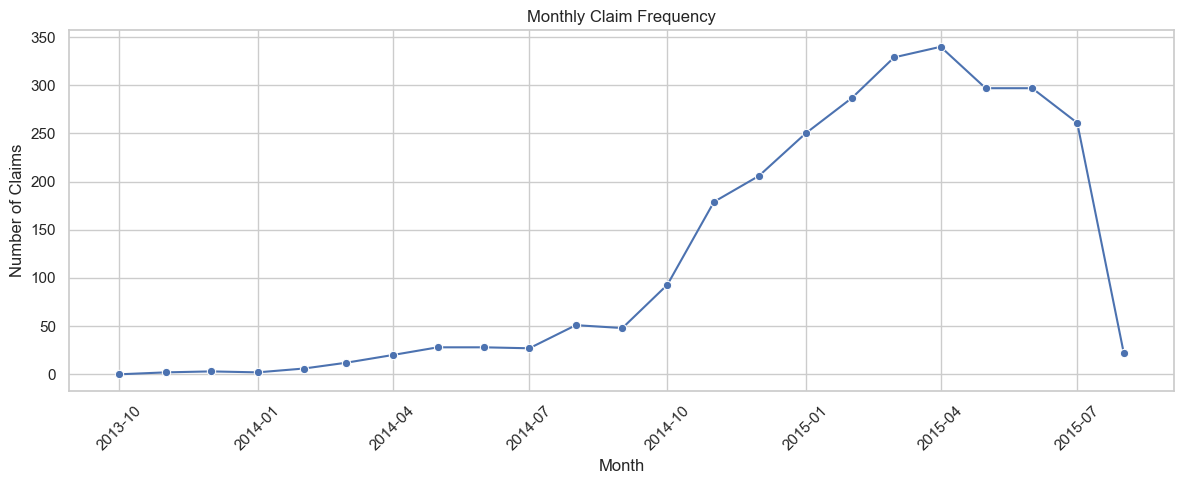

In [8]:
# 📈 Step 4: Plot Monthly Claim Frequency
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_stats, x='TransactionMonth', y='claim_count', marker='o')
plt.title("Monthly Claim Frequency")
plt.xlabel("Month")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/monthly_claim_frequency.png")
plt.show()


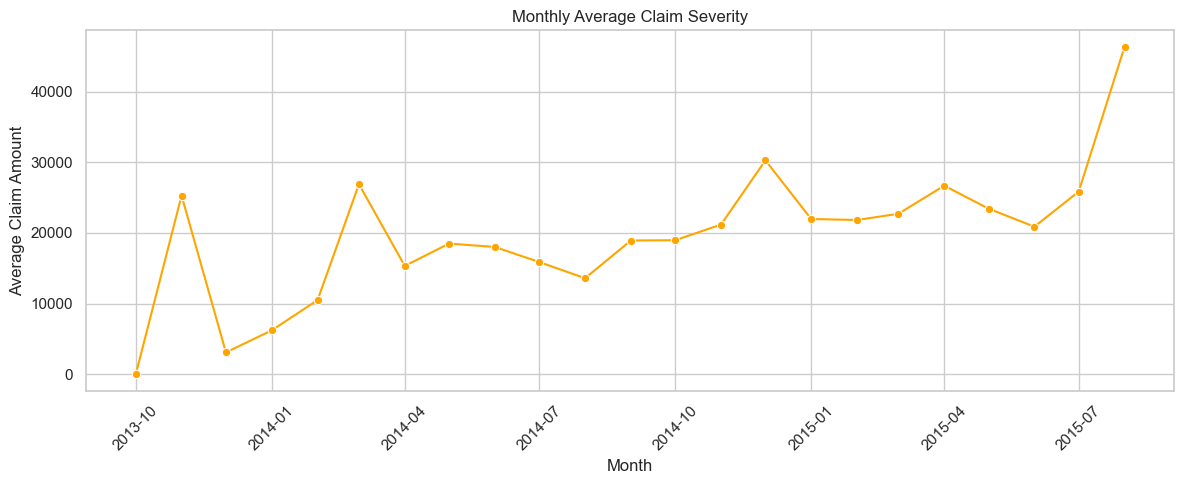

In [9]:
# 📉 Step 5: Plot Monthly Average Claim Severity
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_stats, x='TransactionMonth', y='avg_claim_severity', marker='o', color='orange')
plt.title("Monthly Average Claim Severity")
plt.xlabel("Month")
plt.ylabel("Average Claim Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/monthly_claim_severity.png")
plt.show()


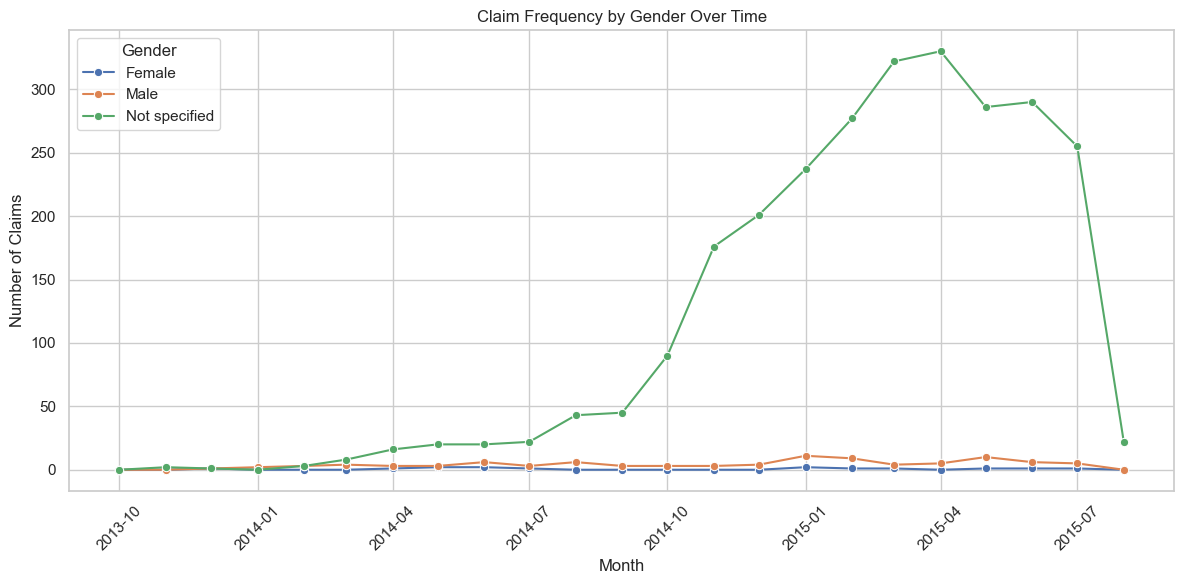

In [10]:
#Claim Frequency by Gender Over Time
# Group by TransactionMonth and Gender
gender_trends = df.groupby([df['TransactionMonth'].dt.to_period('M'), 'Gender'])['TotalClaims'] \
                  .apply(lambda x: (x > 0).sum()) \
                  .reset_index(name='ClaimCount')
gender_trends['TransactionMonth'] = gender_trends['TransactionMonth'].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=gender_trends, x='TransactionMonth', y='ClaimCount', hue='Gender', marker='o')
plt.title("Claim Frequency by Gender Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.savefig("../outputs/claim_frequency_by_gender.png")
plt.show()


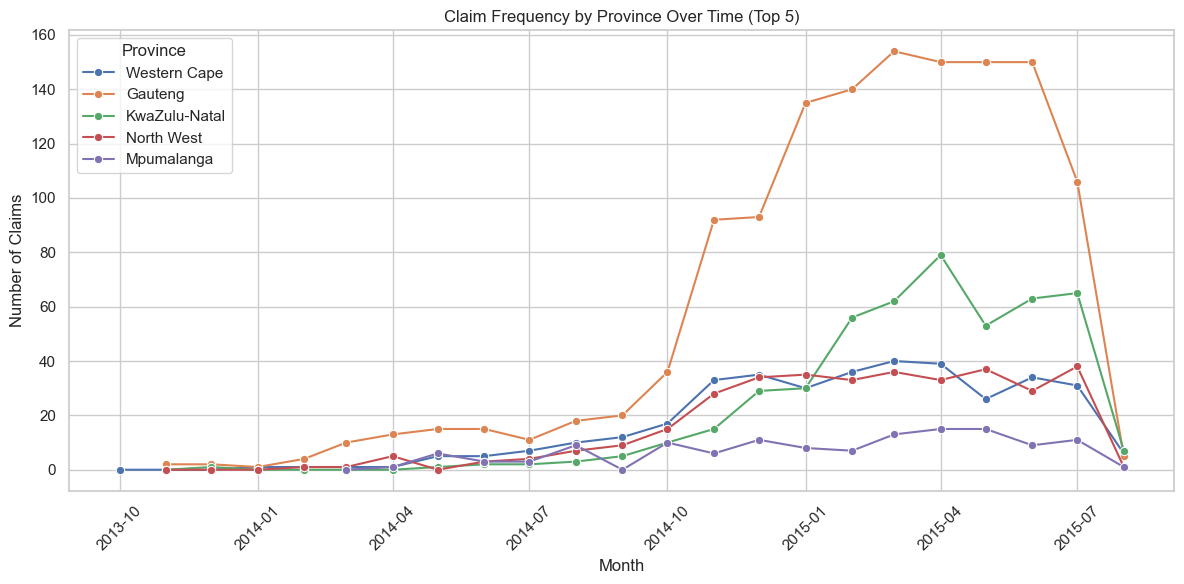

In [11]:
#Claim Frequency by Province Over Time
# Group by TransactionMonth and Province
province_trends = df.groupby([df['TransactionMonth'].dt.to_period('M'), 'Province'])['TotalClaims'] \
                    .apply(lambda x: (x > 0).sum()) \
                    .reset_index(name='ClaimCount')
province_trends['TransactionMonth'] = province_trends['TransactionMonth'].dt.to_timestamp()

# Plot (top 5 provinces only for clarity)
top_provinces = df['Province'].value_counts().nlargest(5).index
filtered = province_trends[province_trends['Province'].isin(top_provinces)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered, x='TransactionMonth', y='ClaimCount', hue='Province', marker='o')
plt.title("Claim Frequency by Province Over Time (Top 5)")
plt.xlabel("Month")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)
plt.legend(title="Province")
plt.tight_layout()
plt.savefig("../outputs/claim_frequency_by_province.png")
plt.show()


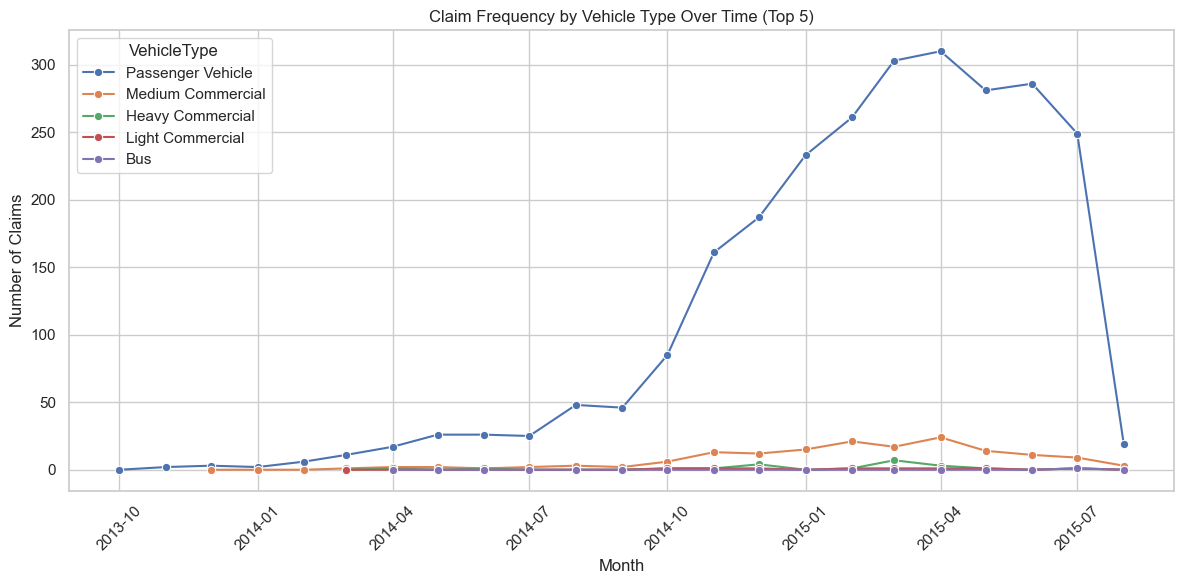

In [12]:
# Group by TransactionMonth and VehicleType
vehicle_trends = df.groupby([df['TransactionMonth'].dt.to_period('M'), 'VehicleType'])['TotalClaims'] \
                   .apply(lambda x: (x > 0).sum()) \
                   .reset_index(name='ClaimCount')
vehicle_trends['TransactionMonth'] = vehicle_trends['TransactionMonth'].dt.to_timestamp()

# Plot (top 5 vehicle types only)
top_vehicles = df['VehicleType'].value_counts().nlargest(5).index
filtered_vehicles = vehicle_trends[vehicle_trends['VehicleType'].isin(top_vehicles)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_vehicles, x='TransactionMonth', y='ClaimCount', hue='VehicleType', marker='o')
plt.title("Claim Frequency by Vehicle Type Over Time (Top 5)")
plt.xlabel("Month")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)
plt.legend(title="VehicleType")
plt.tight_layout()
plt.savefig("../outputs/claim_frequency_by_vehicletype.png")
plt.show()
